# ECDF rare-event threshold analysis

Uses `mfpt_all_thresholds-new-ref.pkl` to find thresholds that best fit an exponential rare-event model.


In [37]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats
import seaborn as sns

from common.consts import long_to_short, proteins
from paper.style_utils import set_paper_style
from common.utils import estimateMFPT
set_paper_style()

plt.rcParams['figure.dpi'] = 160

k = 20


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
data_dir = repo_root / 'data'
mfpt_grid_pkl = data_dir / 'mfpt_all_thresholds-new-ref.pkl'
mfpt_raw_pkl = data_dir / 'mfpt-pace=25000-new-ref.pkl'

mfpt_tables = pd.read_pickle(mfpt_grid_pkl)
all_mfpt = pd.read_pickle(mfpt_raw_pkl)
thresholds = sorted(mfpt_tables.keys(), key=float)

names = list(proteins)


In [ ]:
bad_names = [
    name for name in names
    if long_to_short.get(name) != 'WT' and any(len(all_mfpt[name][thr]) < 50 for thr in thresholds)
]
names = [name for name in names if name not in bad_names]

for name in bad_names:
    for thr in thresholds:
        if len(all_mfpt[name][thr]) < 50:
            print(long_to_short[name], name, thr, len(all_mfpt[name][thr]))


In [40]:
def fit_exp_ecdf_stats(samples):
    x = np.array(samples, float)

    x.sort()
    n = x.size
    def F(t, tau):
        return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, 'expon', args=(0, tau))
    return float(tau), float(D), float(p)


def stats_for_threshold(all_mfpt, names, thr):
    rows = []
    for name in names:
        samples = np.array(all_mfpt[name][thr], float)
        samples = samples[np.isfinite(samples)]
        samples.sort()
        _, k_dyn = estimateMFPT(samples, k)
        s = samples[:k_dyn]

        tau, D, p = fit_exp_ecdf_stats(s)
        rows.append({'name': name, 'n': int(s.size), 'tau': tau, 'D': D, 'p': p})
    return pd.DataFrame(rows).set_index('name')



In [41]:
summary_rows = []
per_threshold = {}

for thr in thresholds:
    df = stats_for_threshold(all_mfpt, names, thr)
    per_threshold[thr] = df
    summary_rows.append({
        'threshold': float(thr),
        'median_D': df['D'].median(),
        'median_p': df['p'].median(),
        'frac_p_gt_0_05': (df['p'] > 0.05).mean(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('threshold')
summary_df


,threshold,median_D,median_p,frac_p_gt_0_05
0,0.28,0.153249,0.313512,0.888889
1,0.30,0.157935,0.309469,0.944444
2,0.32,0.157241,0.345644,0.944444
3,0.34,0.147177,0.406854,0.972222
4,0.36,0.151603,0.383982,1.000000
5,0.38,0.156919,0.458954,1.000000
6,0.40,0.158129,0.353896,1.000000
7,0.42,0.153960,0.426812,0.972222
8,0.44,0.159755,0.460329,0.972222
9,0.46,0.163211,0.395533,0.972222


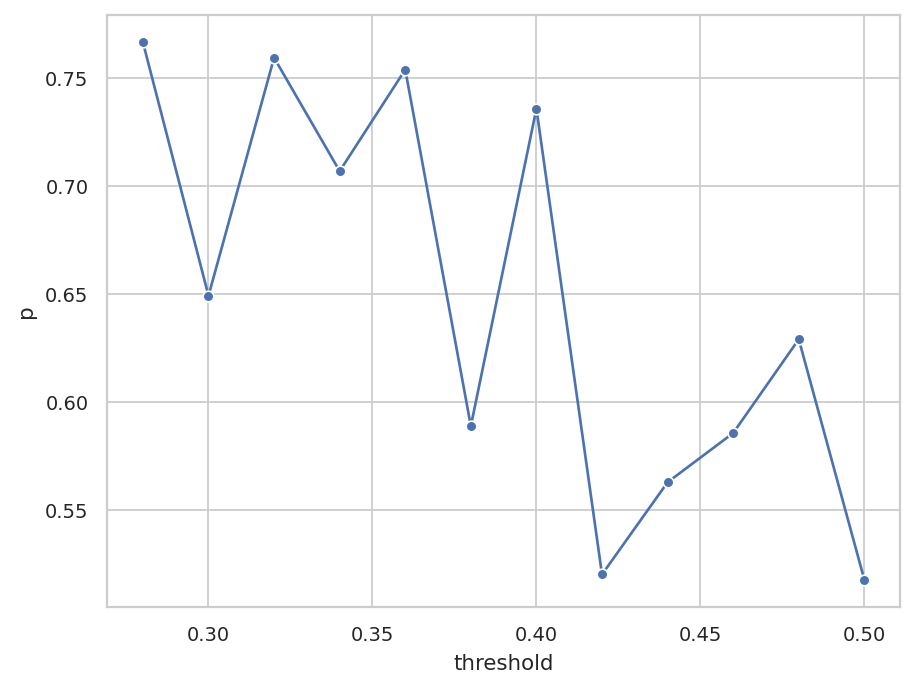

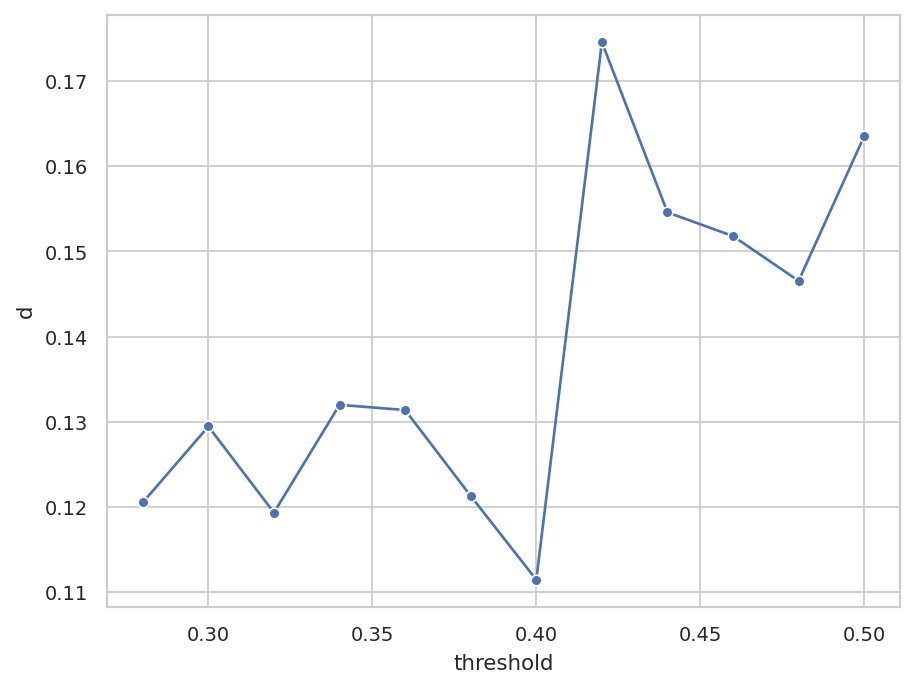

In [48]:
import seaborn as sns
import pandas as pd

p = []
d = []
for thr in thresholds:
    df = stats_for_threshold(all_mfpt, names, thr)
    p.append(df.loc['chignolin', 'p'])
    d.append(df.loc['chignolin', 'D'])

plot_df = pd.DataFrame({
    'threshold': thresholds,
    'p': p,
    'd': d
})

sns.lineplot(
    data=plot_df,
    x='threshold',
    y='p',
    marker='o'
)

plt.show()

sns.lineplot(
    data=plot_df,
    x='threshold',
    y='d',
    marker='o'
)

plt.show()



In [ ]:
best_by_D = summary_df.loc[summary_df['median_D'].idxmin()]
best_by_p = summary_df.loc[summary_df['median_p'].idxmax()]

print(f"Best by median D: thr={best_by_D['threshold']:.3f}, D={best_by_D['median_D']:.3g}, p_med={best_by_D['median_p']:.3g}")
print(f"Best by median p: thr={best_by_p['threshold']:.3f}, p_med={best_by_p['median_p']:.3g}, D_med={best_by_p['median_D']:.3g}")


Best by median D: thr=0.340, D=0.15, p_med=0.407
Best by median p: thr=0.480, p_med=0.476, D_med=0.163


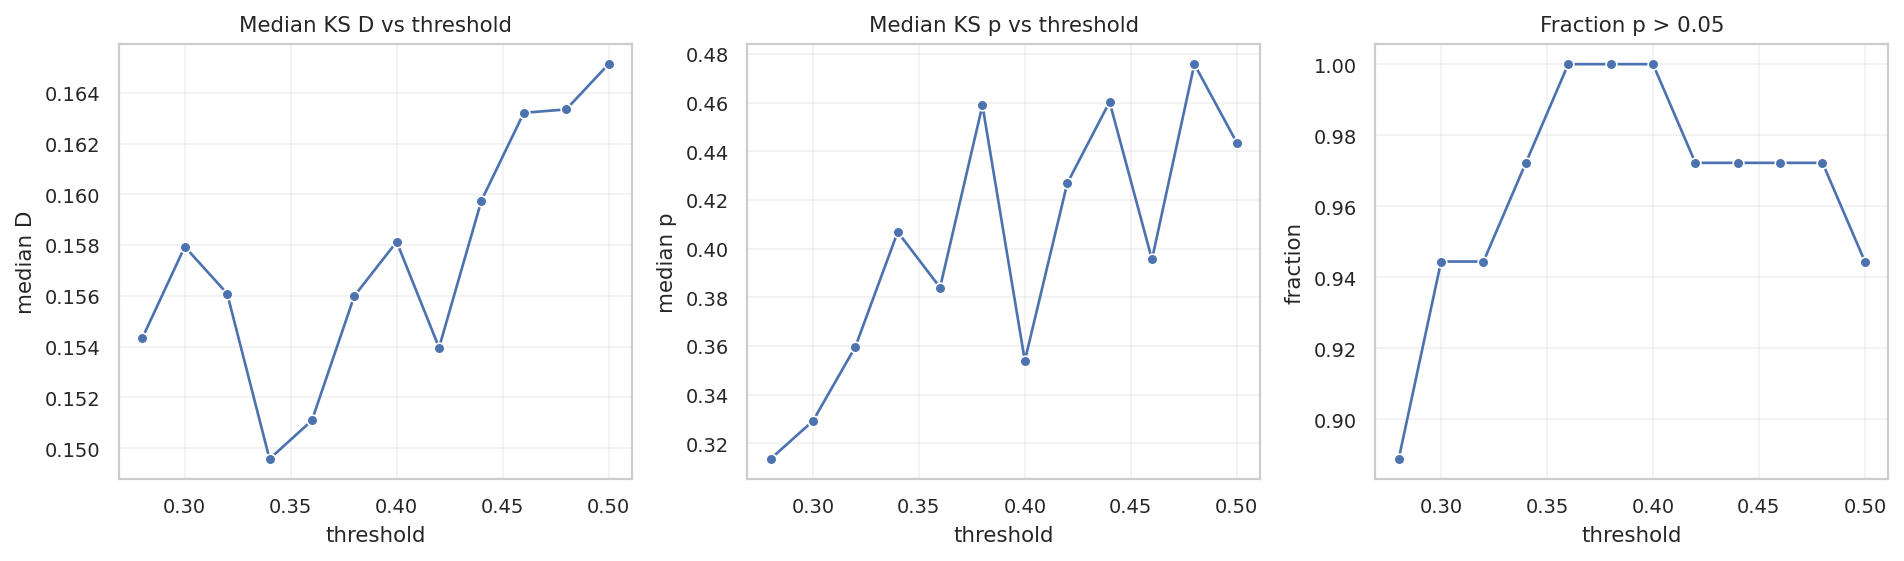

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), squeeze=False)

sns.lineplot(data=summary_df, x='threshold', y='median_D', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Median KS D vs threshold')
axes[0, 0].set_xlabel('threshold')
axes[0, 0].set_ylabel('median D')
axes[0, 0].grid(True, alpha=0.25)

sns.lineplot(data=summary_df, x='threshold', y='median_p', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Median KS p vs threshold')
axes[0, 1].set_xlabel('threshold')
axes[0, 1].set_ylabel('median p')
axes[0, 1].grid(True, alpha=0.25)

sns.lineplot(data=summary_df, x='threshold', y='frac_p_gt_0_05', marker='o', ax=axes[0, 2])
axes[0, 2].set_title('Fraction p > 0.05')
axes[0, 2].set_xlabel('threshold')
axes[0, 2].set_ylabel('fraction')
axes[0, 2].grid(True, alpha=0.25)

fig.tight_layout()
plt.show()


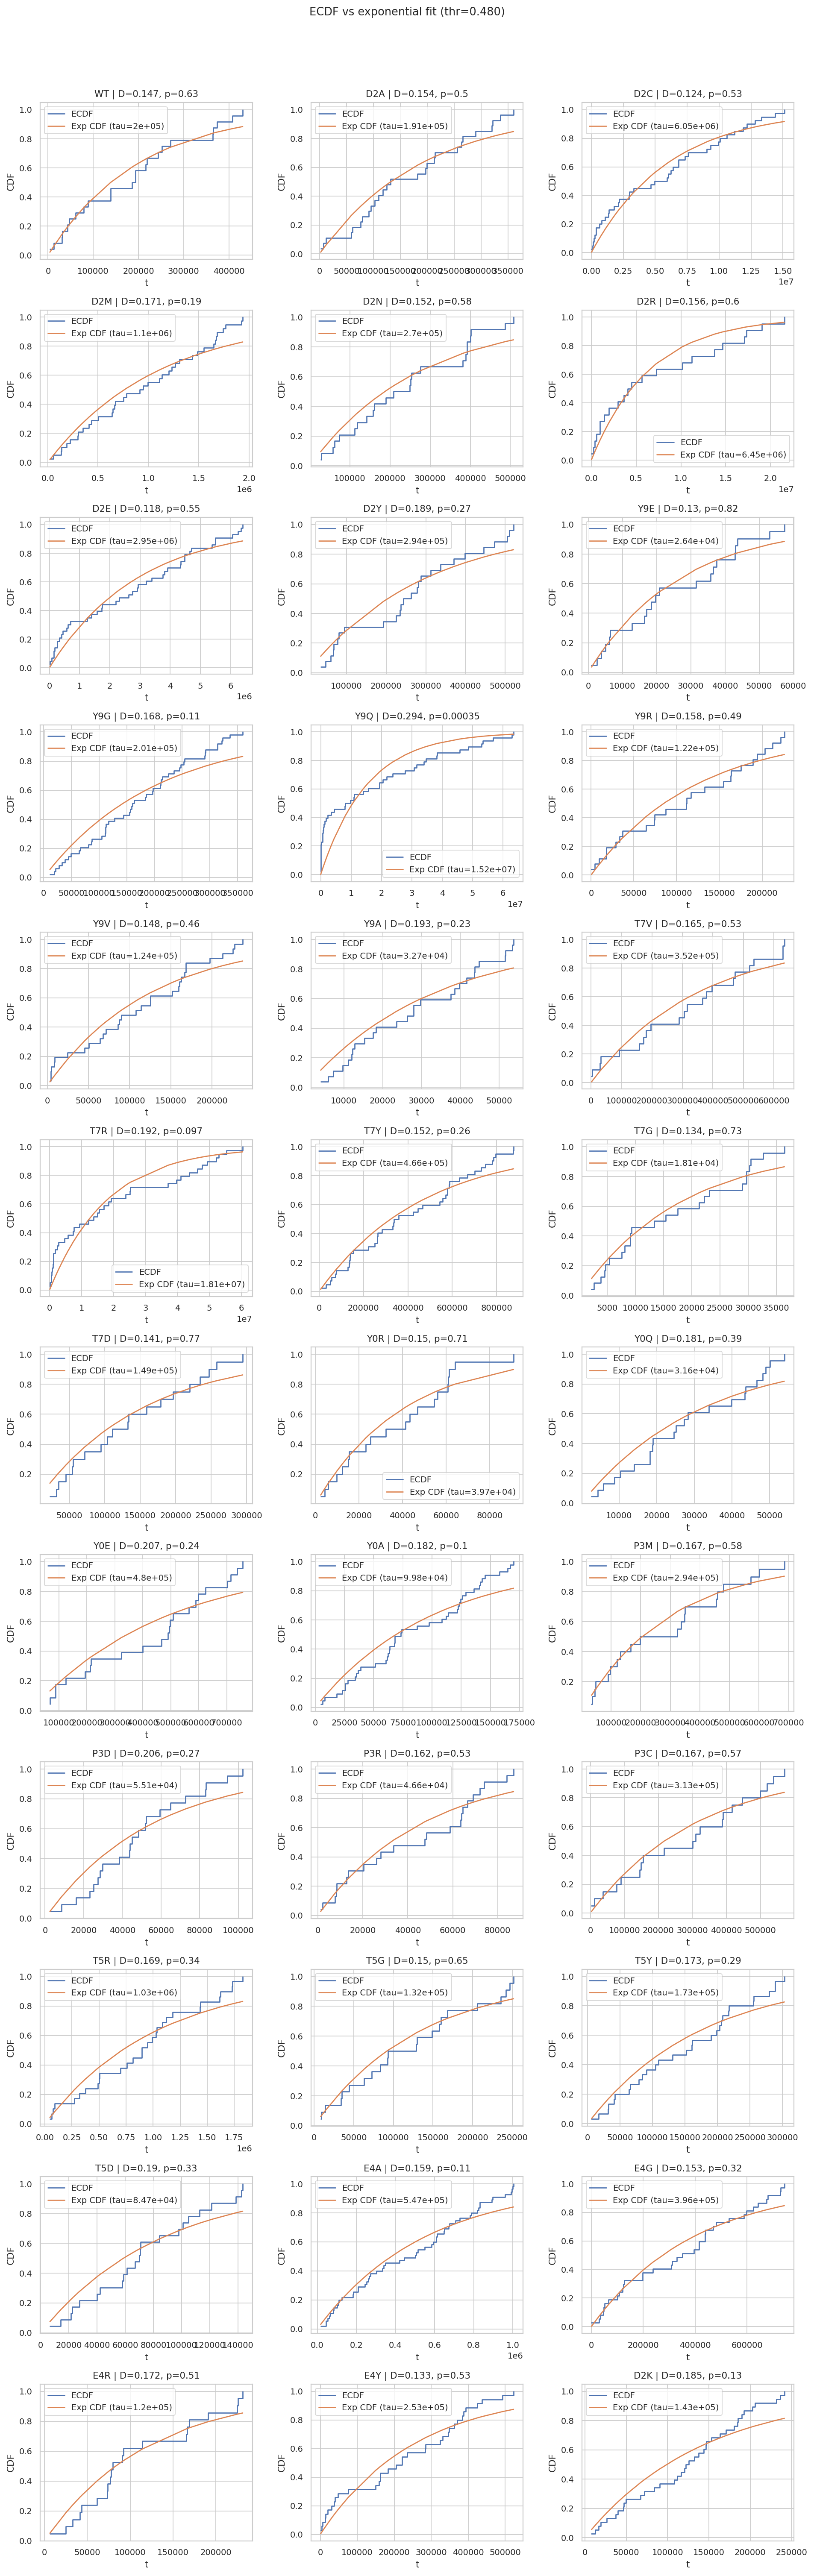

In [ ]:
# ECDF grid for the best-by-median-D threshold
th_ecdf = float(best_by_p['threshold'])

ncols = 3
m = len(names)
nrows = int(np.ceil(m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)

for i, name in enumerate(names):
    r, c = divmod(i, ncols)
    samples = np.array(all_mfpt[name][th_ecdf], float)
    samples = samples[np.isfinite(samples)]
    samples.sort()
    _, k_dyn = estimateMFPT(samples, k)
    s = samples[:k_dyn]
 

    x = s
    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau):
        return 1 - np.exp(-t / tau)
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)
    D, p = stats.kstest(x, 'expon', args=(0, tau))

    ax = axes[r, c]
    ax.step(x, ecdf, where='post', label='ECDF')
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    ax.set_title(f"{long_to_short[name]} | D={D:.3g}, p={p:.2g}")
    ax.set_xlabel('t')
    ax.set_ylabel('CDF')
    ax.legend()

for ax in axes.ravel()[m:]:
    ax.axis('off')

fig.suptitle(f"ECDF vs exponential fit (thr={th_ecdf:.3f})")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
